# Chapter 2: Probability and Statistics

This notebook covers the essential probability and statistics concepts that underpin modern AI and machine learning:

1. Probability Basics - Sample spaces, events, and conditional probability
2. Bayes' Theorem - The foundation of probabilistic reasoning
3. Key Probability Distributions - Bernoulli, Binomial, Gaussian, Categorical
4. Expectation and Variance - Statistical measures and Monte Carlo estimation
5. Multivariate Gaussian - Covariance and correlation in multiple dimensions
6. Maximum Likelihood Estimation - Learning parameters from data

**Why Probability Matters for ML:**
- Neural networks output probability distributions (softmax)
- Training minimizes negative log-likelihood (cross-entropy loss)
- Bayesian methods quantify uncertainty in predictions
- Generative models learn to sample from data distributions

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import bernoulli, binom, norm, multivariate_normal
import ipywidgets as widgets
from ipywidgets import interact, interactive

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

## 1. Probability Basics

Probability provides a mathematical framework for reasoning about uncertainty. Key concepts:

- **Sample Space (Ω)**: Set of all possible outcomes
- **Event**: A subset of the sample space
- **Probability**: P(A) measures likelihood of event A, where 0 ≤ P(A) ≤ 1

In [2]:
# Sample Space Examples

# Coin flip
coin_space = {'H', 'T'}
print(f"Coin flip sample space: {coin_space}")
print(f"P(Heads) = 1/2 = {1/2}")

# Single die roll
die_space = {1, 2, 3, 4, 5, 6}
print(f"\nDie roll sample space: {die_space}")
print(f"P(rolling a 4) = 1/6 = {1/6:.4f}")

# Two dice - sample space has 36 outcomes
two_dice_space = [(i, j) for i in range(1, 7) for j in range(1, 7)]
print(f"\nTwo dice sample space size: {len(two_dice_space)}")

# Event: sum equals 7
sum_7 = [(i, j) for i, j in two_dice_space if i + j == 7]
print(f"Outcomes where sum = 7: {sum_7}")
print(f"P(sum = 7) = {len(sum_7)}/{len(two_dice_space)} = {len(sum_7)/len(two_dice_space):.4f}")

Coin flip sample space: {'H', 'T'}
P(Heads) = 1/2 = 0.5

Die roll sample space: {1, 2, 3, 4, 5, 6}
P(rolling a 4) = 1/6 = 0.1667

Two dice sample space size: 36
Outcomes where sum = 7: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
P(sum = 7) = 6/36 = 0.1667


In [3]:
# Conditional Probability: P(A|B) = P(A ∩ B) / P(B)

# Example: Two cards drawn without replacement
# What's P(2nd card is Ace | 1st card is Ace)?

# Method 1: Direct calculation
# If first card is an Ace, there are 3 Aces left out of 51 cards
p_second_ace_given_first = 3 / 51
print(f"P(2nd Ace | 1st Ace) = 3/51 = {p_second_ace_given_first:.4f}")

# Method 2: Simulation
np.random.seed(42)
n_simulations = 100000
deck = list(range(52))  # 0-3 are Aces

first_ace_count = 0
both_aces_count = 0

for _ in range(n_simulations):
    draw = np.random.choice(deck, size=2, replace=False)
    first_is_ace = draw[0] < 4
    second_is_ace = draw[1] < 4
    
    if first_is_ace:
        first_ace_count += 1
        if second_is_ace:
            both_aces_count += 1

p_simulated = both_aces_count / first_ace_count
print(f"Simulated P(2nd Ace | 1st Ace) = {p_simulated:.4f} (from {n_simulations:,} trials)")

P(2nd Ace | 1st Ace) = 3/51 = 0.0588


Simulated P(2nd Ace | 1st Ace) = 0.0599 (from 100,000 trials)


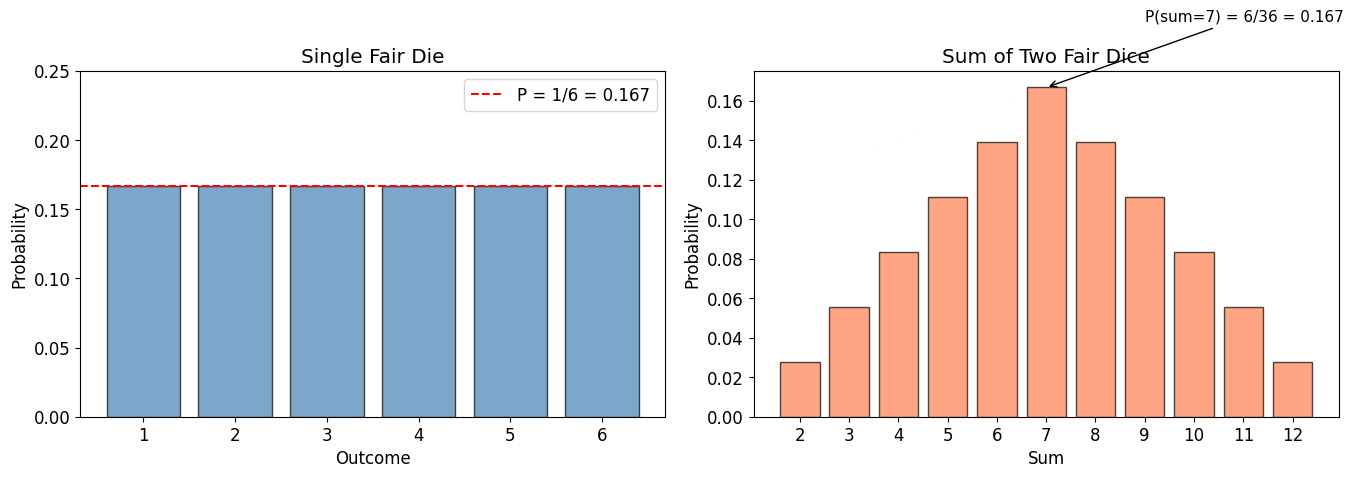

In [4]:
# Visualize dice roll probabilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single die distribution
ax = axes[0]
outcomes = np.arange(1, 7)
probs = np.ones(6) / 6
ax.bar(outcomes, probs, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Outcome')
ax.set_ylabel('Probability')
ax.set_title('Single Fair Die')
ax.set_xticks(outcomes)
ax.set_ylim(0, 0.25)
ax.axhline(y=1/6, color='red', linestyle='--', label=f'P = 1/6 = {1/6:.3f}')
ax.legend()

# Sum of two dice distribution
ax = axes[1]
sums = np.arange(2, 13)
sum_counts = np.array([len([1 for i, j in two_dice_space if i + j == s]) for s in sums])
sum_probs = sum_counts / 36

ax.bar(sums, sum_probs, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Sum')
ax.set_ylabel('Probability')
ax.set_title('Sum of Two Fair Dice')
ax.set_xticks(sums)

# Annotate the most likely outcome
ax.annotate(f'P(sum=7) = 6/36 = {6/36:.3f}', xy=(7, 6/36), xytext=(9, 0.2),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11)

plt.tight_layout()
plt.show()

## 2. Bayes' Theorem

Bayes' theorem relates conditional probabilities and enables us to update beliefs given new evidence:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Where:
- $P(A|B)$: Posterior probability (updated belief after seeing evidence B)
- $P(B|A)$: Likelihood (probability of evidence given hypothesis)
- $P(A)$: Prior probability (initial belief)
- $P(B)$: Evidence (normalizing constant)

In [5]:
# Spam Filter Example using Bayes' Theorem
#
# Given: 
# - 30% of emails are spam: P(Spam) = 0.30
# - 80% of spam contains word "free": P(Free|Spam) = 0.80
# - 10% of non-spam contains word "free": P(Free|Not Spam) = 0.10
#
# Question: If an email contains "free", what's P(Spam|Free)?

# Prior probabilities
p_spam = 0.30
p_not_spam = 1 - p_spam

# Likelihoods
p_free_given_spam = 0.80
p_free_given_not_spam = 0.10

print("=" * 50)
print("SPAM FILTER: Bayes' Theorem Step-by-Step")
print("=" * 50)

print("\n[Given Information]")
print(f"  P(Spam)            = {p_spam:.2f}")
print(f"  P(Not Spam)        = {p_not_spam:.2f}")
print(f"  P(Free | Spam)     = {p_free_given_spam:.2f}")
print(f"  P(Free | Not Spam) = {p_free_given_not_spam:.2f}")

SPAM FILTER: Bayes' Theorem Step-by-Step

[Given Information]
  P(Spam)            = 0.30
  P(Not Spam)        = 0.70
  P(Free | Spam)     = 0.80
  P(Free | Not Spam) = 0.10


In [6]:
# Step 1: Calculate P(Free) using the law of total probability
# P(Free) = P(Free|Spam)P(Spam) + P(Free|Not Spam)P(Not Spam)

p_free = (p_free_given_spam * p_spam) + (p_free_given_not_spam * p_not_spam)

print("\n[Step 1: Calculate P(Free)]")
print(f"  P(Free) = P(Free|Spam) * P(Spam) + P(Free|Not Spam) * P(Not Spam)")
print(f"  P(Free) = {p_free_given_spam} * {p_spam} + {p_free_given_not_spam} * {p_not_spam}")
print(f"  P(Free) = {p_free_given_spam * p_spam:.2f} + {p_free_given_not_spam * p_not_spam:.2f}")
print(f"  P(Free) = {p_free:.2f}")

# Step 2: Apply Bayes' Theorem
# P(Spam|Free) = P(Free|Spam) * P(Spam) / P(Free)

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("\n[Step 2: Apply Bayes' Theorem]")
print(f"  P(Spam|Free) = P(Free|Spam) * P(Spam) / P(Free)")
print(f"  P(Spam|Free) = {p_free_given_spam} * {p_spam} / {p_free:.2f}")
print(f"  P(Spam|Free) = {p_free_given_spam * p_spam:.2f} / {p_free:.2f}")
print(f"  P(Spam|Free) = {p_spam_given_free:.4f}")

print("\n" + "=" * 50)
print(f"RESULT: If an email contains 'free', there's a {p_spam_given_free*100:.1f}% chance it's spam.")
print(f"The prior belief of {p_spam*100:.0f}% updated to {p_spam_given_free*100:.1f}% after seeing 'free'.")
print("=" * 50)


[Step 1: Calculate P(Free)]
  P(Free) = P(Free|Spam) * P(Spam) + P(Free|Not Spam) * P(Not Spam)
  P(Free) = 0.8 * 0.3 + 0.1 * 0.7
  P(Free) = 0.24 + 0.07
  P(Free) = 0.31

[Step 2: Apply Bayes' Theorem]
  P(Spam|Free) = P(Free|Spam) * P(Spam) / P(Free)
  P(Spam|Free) = 0.8 * 0.3 / 0.31
  P(Spam|Free) = 0.24 / 0.31
  P(Spam|Free) = 0.7742

RESULT: If an email contains 'free', there's a 77.4% chance it's spam.
The prior belief of 30% updated to 77.4% after seeing 'free'.


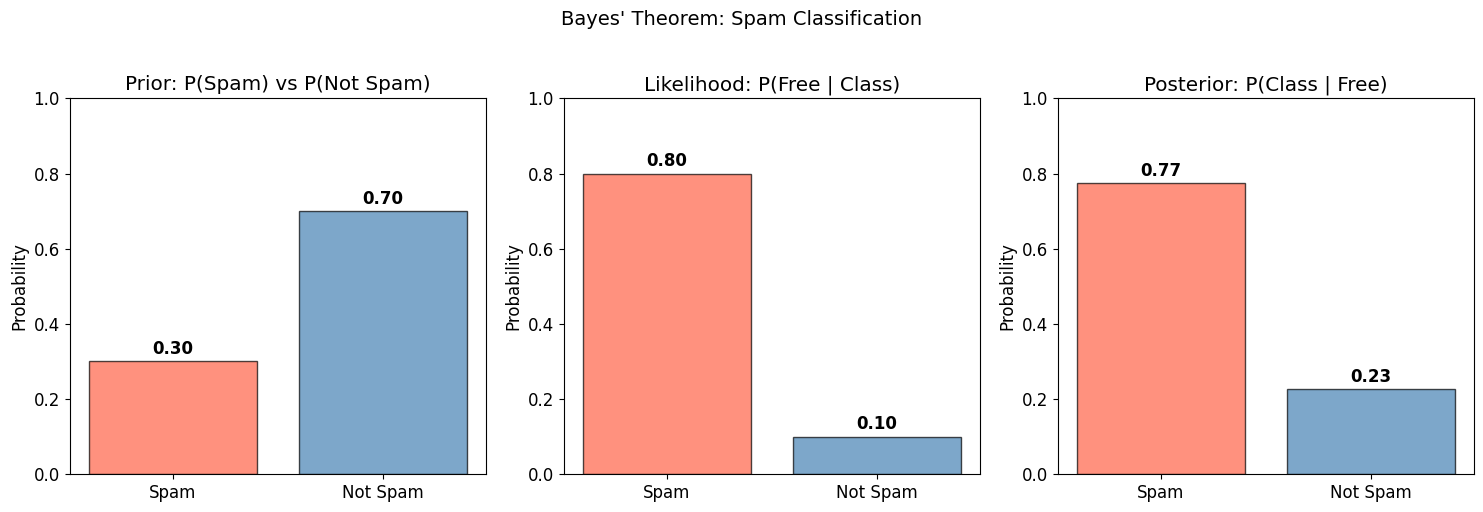

In [7]:
# Visualize Bayes' Theorem with the spam example
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Prior probabilities
ax = axes[0]
labels = ['Spam', 'Not Spam']
priors = [p_spam, p_not_spam]
colors = ['tomato', 'steelblue']
ax.bar(labels, priors, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Probability')
ax.set_title('Prior: P(Spam) vs P(Not Spam)')
ax.set_ylim(0, 1)
for i, v in enumerate(priors):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Likelihoods
ax = axes[1]
likelihoods = [p_free_given_spam, p_free_given_not_spam]
ax.bar(labels, likelihoods, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Probability')
ax.set_title('Likelihood: P(Free | Class)')
ax.set_ylim(0, 1)
for i, v in enumerate(likelihoods):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

# Plot 3: Posterior probabilities
ax = axes[2]
p_not_spam_given_free = 1 - p_spam_given_free
posteriors = [p_spam_given_free, p_not_spam_given_free]
ax.bar(labels, posteriors, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Probability')
ax.set_title('Posterior: P(Class | Free)')
ax.set_ylim(0, 1)
for i, v in enumerate(posteriors):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle("Bayes' Theorem: Spam Classification", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Key Probability Distributions

Probability distributions describe the likelihood of different outcomes. Understanding these distributions is crucial for:

- **Bernoulli/Binomial**: Binary classification, coin flips
- **Categorical**: Multi-class classification (softmax outputs)
- **Gaussian (Normal)**: Continuous data, measurement errors, latent variables

In [8]:
# Bernoulli and Binomial Distributions

# Bernoulli: Single trial with probability p of success
p = 0.7
bernoulli_dist = bernoulli(p)

print("Bernoulli Distribution (single coin flip, P(heads)=0.7)")
print(f"  P(X=0) = {bernoulli_dist.pmf(0):.2f}")
print(f"  P(X=1) = {bernoulli_dist.pmf(1):.2f}")
print(f"  Mean = {bernoulli_dist.mean():.2f}")
print(f"  Variance = {bernoulli_dist.var():.2f}")

# Binomial: n independent Bernoulli trials
n = 10
binomial_dist = binom(n, p)

print(f"\nBinomial Distribution (n={n} flips, p={p})")
print(f"  Mean = n*p = {binomial_dist.mean():.2f}")
print(f"  Variance = n*p*(1-p) = {binomial_dist.var():.2f}")
print(f"  P(X=7) = {binomial_dist.pmf(7):.4f}")
print(f"  P(X>=7) = {1 - binomial_dist.cdf(6):.4f}")

Bernoulli Distribution (single coin flip, P(heads)=0.7)
  P(X=0) = 0.30
  P(X=1) = 0.70
  Mean = 0.70
  Variance = 0.21

Binomial Distribution (n=10 flips, p=0.7)
  Mean = n*p = 7.00
  Variance = n*p*(1-p) = 2.10
  P(X=7) = 0.2668
  P(X>=7) = 0.6496


In [9]:
# Interactive Binomial Distribution
def plot_binomial(n=10, p=0.5):
    """Plot binomial distribution with given parameters."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    k = np.arange(0, n + 1)
    pmf = binom.pmf(k, n, p)
    
    bars = ax.bar(k, pmf, color='steelblue', edgecolor='black', alpha=0.7)
    
    # Highlight the mean
    mean = n * p
    ax.axvline(x=mean, color='red', linestyle='--', linewidth=2, 
               label=f'Mean = {mean:.1f}')
    
    ax.set_xlabel('Number of Successes (k)')
    ax.set_ylabel('Probability P(X=k)')
    ax.set_title(f'Binomial Distribution: n={n}, p={p:.2f}')
    ax.set_xticks(k)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    variance = n * p * (1 - p)
    ax.text(0.98, 0.95, f'Variance = {variance:.2f}\nStd Dev = {np.sqrt(variance):.2f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_binomial,
         n=widgets.IntSlider(min=1, max=30, step=1, value=10, description='n (trials)'),
         p=widgets.FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5, description='p (prob)'));

interactive(children=(IntSlider(value=10, description='n (trials)', max=30, min=1), FloatSlider(value=0.5, des…

In [10]:
# Gaussian (Normal) Distribution

# Standard normal: mean=0, std=1
standard_normal = norm(loc=0, scale=1)

print("Standard Normal Distribution N(0, 1)")
print(f"  P(X < 0) = {standard_normal.cdf(0):.4f}")
print(f"  P(-1 < X < 1) = {standard_normal.cdf(1) - standard_normal.cdf(-1):.4f} (68-95-99.7 rule)")
print(f"  P(-2 < X < 2) = {standard_normal.cdf(2) - standard_normal.cdf(-2):.4f}")
print(f"  P(-3 < X < 3) = {standard_normal.cdf(3) - standard_normal.cdf(-3):.4f}")

# PDF at various points
x_vals = [-2, -1, 0, 1, 2]
print(f"\n  PDF values:")
for x in x_vals:
    print(f"    f({x:2d}) = {standard_normal.pdf(x):.4f}")

Standard Normal Distribution N(0, 1)
  P(X < 0) = 0.5000
  P(-1 < X < 1) = 0.6827 (68-95-99.7 rule)
  P(-2 < X < 2) = 0.9545
  P(-3 < X < 3) = 0.9973

  PDF values:
    f(-2) = 0.0540
    f(-1) = 0.2420
    f( 0) = 0.3989
    f( 1) = 0.2420
    f( 2) = 0.0540


In [11]:
# Interactive Gaussian Distribution
def plot_gaussian(mu=0, sigma=1):
    """Plot Gaussian distribution with given parameters."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    pdf = norm.pdf(x, loc=mu, scale=sigma)
    
    ax.plot(x, pdf, 'b-', linewidth=2, label=f'N({mu}, {sigma}$^2$)')
    ax.fill_between(x, pdf, alpha=0.3)
    
    # Mark mean and +/- 1 std
    ax.axvline(x=mu, color='red', linestyle='-', linewidth=2, label=f'Mean = {mu}')
    ax.axvline(x=mu - sigma, color='green', linestyle='--', linewidth=1.5, label=f'$\\mu \\pm \\sigma$')
    ax.axvline(x=mu + sigma, color='green', linestyle='--', linewidth=1.5)
    
    # Shade 1-sigma region
    x_fill = np.linspace(mu - sigma, mu + sigma, 100)
    ax.fill_between(x_fill, norm.pdf(x_fill, mu, sigma), color='green', alpha=0.3)
    
    ax.set_xlabel('x')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Gaussian Distribution: $\\mu$={mu}, $\\sigma$={sigma}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add annotation for area under curve
    area_1sigma = norm.cdf(mu + sigma, mu, sigma) - norm.cdf(mu - sigma, mu, sigma)
    ax.text(0.02, 0.95, f'Area within $\\pm$1$\\sigma$: {area_1sigma:.1%}',
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_gaussian,
         mu=widgets.FloatSlider(min=-5, max=5, step=0.5, value=0, description='Mean (μ)'),
         sigma=widgets.FloatSlider(min=0.5, max=3, step=0.25, value=1, description='Std (σ)'));

interactive(children=(FloatSlider(value=0.0, description='Mean (μ)', max=5.0, min=-5.0, step=0.5), FloatSlider…

Categorical Distribution (Softmax Output Example)
  Classes: ['Cat', 'Dog', 'Bird', 'Fish']
  Probabilities: [0.45 0.3  0.15 0.1 ]
  Sum of probabilities: 1.00 (must equal 1)

  Sampled 1000 times:
    Bird: 143 (expected ~150)
    Cat: 461 (expected ~450)
    Dog: 296 (expected ~300)
    Fish: 100 (expected ~100)


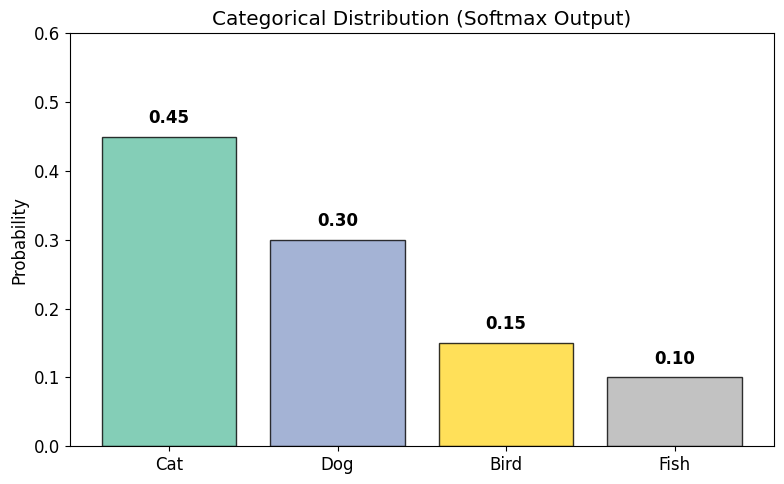

In [12]:
# Categorical Distribution (Discrete over multiple classes)
# This is what softmax outputs in neural networks!

# Example: 4-class classification (cat, dog, bird, fish)
classes = ['Cat', 'Dog', 'Bird', 'Fish']
probabilities = np.array([0.45, 0.30, 0.15, 0.10])

print("Categorical Distribution (Softmax Output Example)")
print(f"  Classes: {classes}")
print(f"  Probabilities: {probabilities}")
print(f"  Sum of probabilities: {probabilities.sum():.2f} (must equal 1)")

# Sampling from categorical
np.random.seed(42)
samples = np.random.choice(classes, size=1000, p=probabilities)
unique, counts = np.unique(samples, return_counts=True)

print(f"\n  Sampled 1000 times:")
for cls, cnt in zip(unique, counts):
    expected = probabilities[classes.index(cls)] * 1000
    print(f"    {cls}: {cnt} (expected ~{expected:.0f})")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))
ax.bar(classes, probabilities, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Probability')
ax.set_title('Categorical Distribution (Softmax Output)')
ax.set_ylim(0, 0.6)
for i, (cls, p) in enumerate(zip(classes, probabilities)):
    ax.text(i, p + 0.02, f'{p:.2f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Expectation and Variance

**Expectation (Mean)**: The average value we expect from a random variable.

$$E[X] = \sum_x x \cdot P(X=x) \quad \text{(discrete)}$$
$$E[X] = \int x \cdot f(x) dx \quad \text{(continuous)}$$

**Variance**: Measures spread/dispersion around the mean.

$$\text{Var}(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2$$

In [13]:
# Computing expectation and variance for discrete distributions

# Fair die
outcomes = np.array([1, 2, 3, 4, 5, 6])
probs = np.ones(6) / 6

expectation = np.sum(outcomes * probs)
expectation_x2 = np.sum(outcomes**2 * probs)
variance = expectation_x2 - expectation**2

print("Fair Die Roll:")
print(f"  E[X] = Σ x·P(x) = {expectation:.4f}")
print(f"  E[X²] = Σ x²·P(x) = {expectation_x2:.4f}")
print(f"  Var(X) = E[X²] - (E[X])² = {expectation_x2:.4f} - {expectation**2:.4f} = {variance:.4f}")
print(f"  Std(X) = √Var(X) = {np.sqrt(variance):.4f}")

# Loaded die (favors higher numbers)
loaded_probs = np.array([0.05, 0.10, 0.10, 0.15, 0.25, 0.35])
loaded_expectation = np.sum(outcomes * loaded_probs)
loaded_expectation_x2 = np.sum(outcomes**2 * loaded_probs)
loaded_variance = loaded_expectation_x2 - loaded_expectation**2

print(f"\nLoaded Die (favors high):")
print(f"  Probabilities: {loaded_probs}")
print(f"  E[X] = {loaded_expectation:.4f}")
print(f"  Var(X) = {loaded_variance:.4f}")
print(f"  Std(X) = {np.sqrt(loaded_variance):.4f}")

Fair Die Roll:
  E[X] = Σ x·P(x) = 3.5000
  E[X²] = Σ x²·P(x) = 15.1667
  Var(X) = E[X²] - (E[X])² = 15.1667 - 12.2500 = 2.9167
  Std(X) = √Var(X) = 1.7078

Loaded Die (favors high):
  Probabilities: [0.05 0.1  0.1  0.15 0.25 0.35]
  E[X] = 4.5000
  Var(X) = 2.3500
  Std(X) = 1.5330


In [14]:
# Monte Carlo Estimation of Expectation
# We can estimate E[f(X)] by sampling!

# True values for N(0,1)
print("Monte Carlo Estimation for Standard Normal N(0,1)")
print("="*50)

sample_sizes = [100, 1000, 10000, 100000]
np.random.seed(42)

print(f"\n{'n':<10} {'E[X]':>12} {'E[X²]':>12} {'Var(X)':>12}")
print("-"*50)
print(f"{'True':10} {'0.0000':>12} {'1.0000':>12} {'1.0000':>12}")

for n in sample_sizes:
    samples = np.random.randn(n)
    est_mean = np.mean(samples)
    est_mean_x2 = np.mean(samples**2)
    est_var = np.var(samples)
    print(f"{n:<10} {est_mean:>12.4f} {est_mean_x2:>12.4f} {est_var:>12.4f}")

print("\nNote: Estimates converge to true values as n increases (Law of Large Numbers)")

Monte Carlo Estimation for Standard Normal N(0,1)

n                  E[X]        E[X²]       Var(X)
--------------------------------------------------
True             0.0000       1.0000       1.0000
100             -0.1038       0.8273       0.8165
1000             0.0457       0.9675       0.9654
10000           -0.0098       1.0048       1.0047
100000           0.0025       1.0010       1.0010

Note: Estimates converge to true values as n increases (Law of Large Numbers)


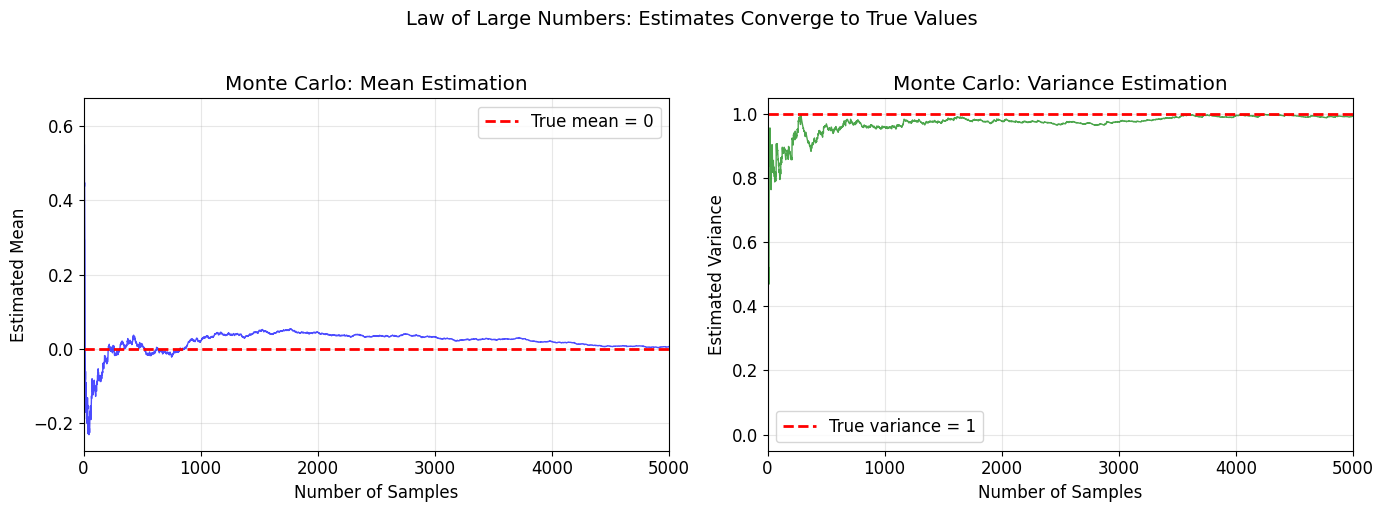

In [15]:
# Visualize convergence of Monte Carlo estimates
np.random.seed(42)
n_max = 5000
samples = np.random.randn(n_max)

# Running estimates
running_mean = np.cumsum(samples) / np.arange(1, n_max + 1)
running_var = np.array([np.var(samples[:i+1]) for i in range(n_max)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean convergence
ax = axes[0]
ax.plot(running_mean, 'b-', linewidth=1, alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='True mean = 0')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Estimated Mean')
ax.set_title('Monte Carlo: Mean Estimation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, n_max)

# Variance convergence
ax = axes[1]
ax.plot(running_var, 'g-', linewidth=1, alpha=0.7)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='True variance = 1')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('Estimated Variance')
ax.set_title('Monte Carlo: Variance Estimation')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, n_max)

plt.suptitle('Law of Large Numbers: Estimates Converge to True Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Multivariate Gaussian Distribution

The multivariate Gaussian extends to multiple correlated variables:

$$p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\mu)^T\Sigma^{-1}(\mathbf{x}-\mu)\right)$$

Where:
- $\mu$: Mean vector (d-dimensional)
- $\Sigma$: Covariance matrix (d x d, symmetric positive definite)
- $|\Sigma|$: Determinant of covariance matrix

In [16]:
# 2D Gaussian with different covariances
np.random.seed(42)

# Mean vector
mu = np.array([0, 0])

# Different covariance matrices
# 1. Independent (diagonal covariance)
cov_independent = np.array([[1.0, 0.0],
                            [0.0, 1.0]])

# 2. Positive correlation
cov_positive = np.array([[1.0, 0.8],
                         [0.8, 1.0]])

# 3. Negative correlation
cov_negative = np.array([[1.0, -0.8],
                         [-0.8, 1.0]])

# 4. Different variances
cov_different = np.array([[2.0, 0.5],
                          [0.5, 0.5]])

covariances = [
    (cov_independent, 'Independent (ρ=0)'),
    (cov_positive, 'Positive Corr (ρ=0.8)'),
    (cov_negative, 'Negative Corr (ρ=-0.8)'),
    (cov_different, 'Different Variances')
]

print("Covariance Matrices:")
for cov, name in covariances:
    print(f"\n{name}:")
    print(cov)

Covariance Matrices:

Independent (ρ=0):
[[1. 0.]
 [0. 1.]]

Positive Corr (ρ=0.8):
[[1.  0.8]
 [0.8 1. ]]

Negative Corr (ρ=-0.8):
[[ 1.  -0.8]
 [-0.8  1. ]]

Different Variances:
[[2.  0.5]
 [0.5 0.5]]


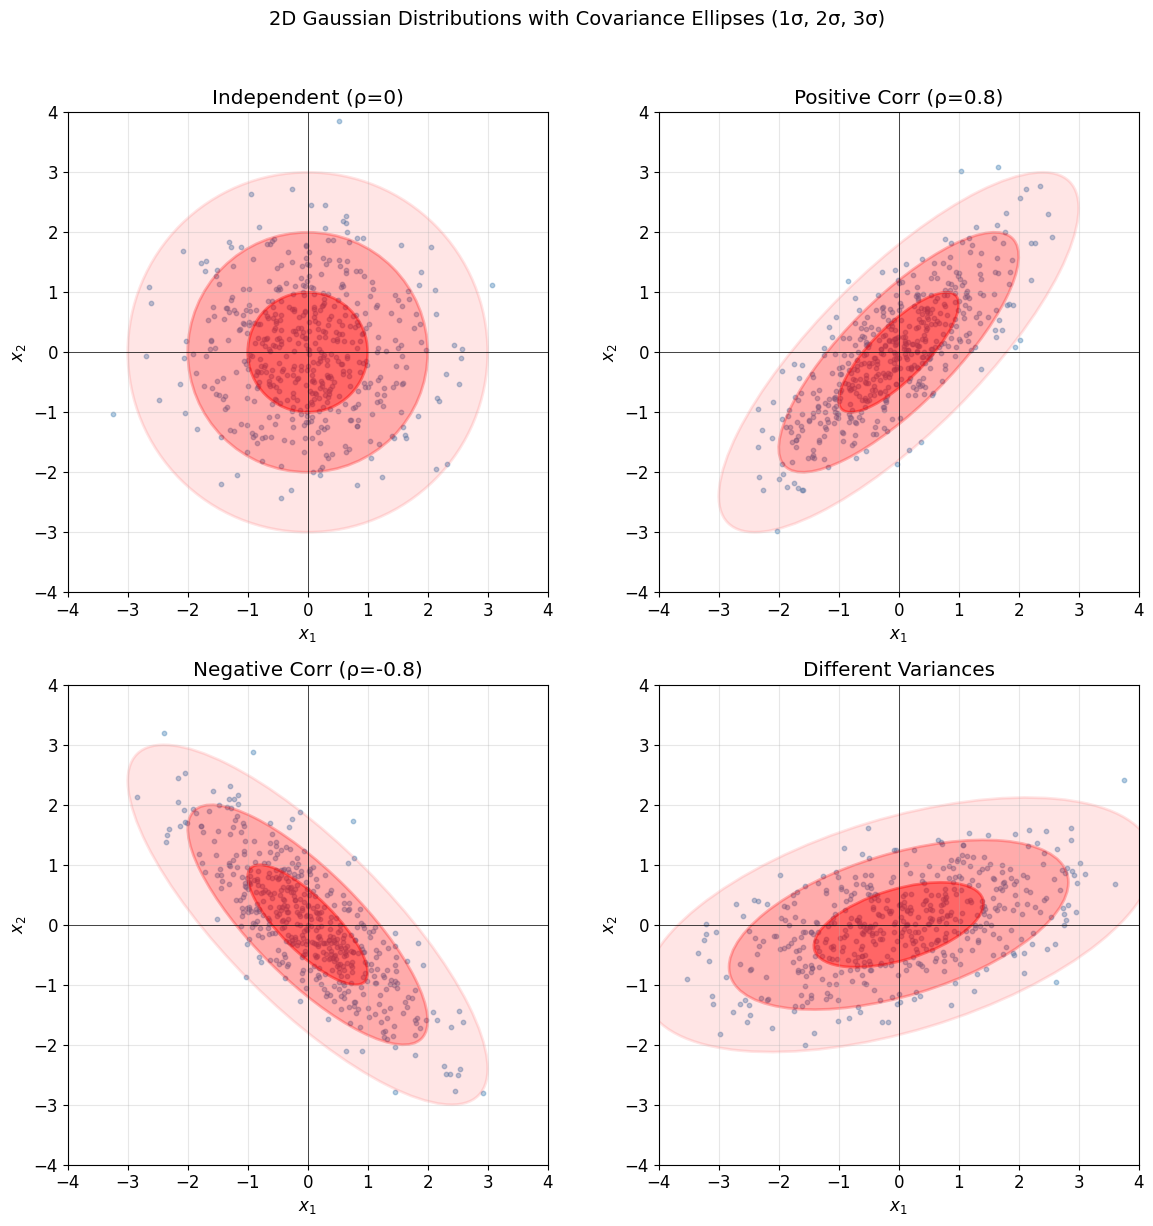

In [17]:
# Visualize 2D Gaussians with covariance ellipses
from matplotlib.patches import Ellipse

def plot_cov_ellipse(ax, mean, cov, n_std=2, **kwargs):
    """Plot confidence ellipse for 2D Gaussian."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (cov, name) in zip(axes, covariances):
    # Generate samples
    samples = np.random.multivariate_normal(mu, cov, 500)
    
    # Plot samples
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.4, s=10, color='steelblue')
    
    # Plot covariance ellipses (1, 2, 3 std)
    for n_std, alpha in [(1, 0.4), (2, 0.25), (3, 0.1)]:
        plot_cov_ellipse(ax, mu, cov, n_std=n_std, 
                        facecolor='red', alpha=alpha, edgecolor='red', linewidth=2)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(name)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('2D Gaussian Distributions with Covariance Ellipses (1σ, 2σ, 3σ)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Interactive exploration of correlation
def plot_correlation(rho=0.0):
    """Visualize effect of correlation on 2D Gaussian."""
    np.random.seed(42)
    
    # Build covariance matrix
    cov = np.array([[1.0, rho],
                    [rho, 1.0]])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Scatter plot with ellipse
    ax = axes[0]
    samples = np.random.multivariate_normal([0, 0], cov, 500)
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.4, s=20, color='steelblue')
    
    for n_std, alpha in [(1, 0.4), (2, 0.25)]:
        plot_cov_ellipse(ax, [0, 0], cov, n_std=n_std,
                        facecolor='red', alpha=alpha, edgecolor='red', linewidth=2)
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'Samples with Correlation ρ = {rho:.2f}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # Right: Contour plot
    ax = axes[1]
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    rv = multivariate_normal([0, 0], cov)
    Z = rv.pdf(pos)
    
    contour = ax.contourf(X, Y, Z, levels=20, cmap='Blues')
    ax.contour(X, Y, Z, levels=10, colors='darkblue', linewidths=0.5, alpha=0.5)
    plt.colorbar(contour, ax=ax, label='Probability Density')
    
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'PDF Contours')
    ax.set_aspect('equal')
    
    plt.suptitle(f'Bivariate Gaussian: Covariance Matrix = [[1, {rho:.2f}], [{rho:.2f}, 1]]', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(plot_correlation,
         rho=widgets.FloatSlider(min=-0.95, max=0.95, step=0.05, value=0, description='Correlation (ρ)'));

interactive(children=(FloatSlider(value=0.0, description='Correlation (ρ)', max=0.95, min=-0.95, step=0.05), O…

## 6. Maximum Likelihood Estimation (MLE)

MLE finds the parameters that maximize the probability of observing our data:

$$\hat{\theta}_{MLE} = \arg\max_\theta \prod_{i=1}^n p(x_i | \theta) = \arg\max_\theta \sum_{i=1}^n \log p(x_i | \theta)$$

For a Gaussian with unknown mean and variance:
- $\hat{\mu}_{MLE} = \frac{1}{n}\sum_{i=1}^n x_i$ (sample mean)
- $\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$ (sample variance)

In [19]:
# Generate data from a Gaussian with known parameters
np.random.seed(42)
true_mu = 5.0
true_sigma = 2.0
n_samples = 100

data = np.random.normal(true_mu, true_sigma, n_samples)

print(f"True parameters: μ = {true_mu}, σ = {true_sigma}")
print(f"Generated {n_samples} samples")
print(f"\nSample statistics:")
print(f"  Min: {data.min():.4f}")
print(f"  Max: {data.max():.4f}")
print(f"  Sample mean: {data.mean():.4f}")
print(f"  Sample std: {data.std():.4f}")

True parameters: μ = 5.0, σ = 2.0
Generated 100 samples

Sample statistics:
  Min: -0.2395
  Max: 8.7046
  Sample mean: 4.7923
  Sample std: 1.8072


In [20]:
# MLE estimates
mu_mle = np.mean(data)
sigma_mle = np.std(data)  # MLE uses n, not n-1

print("Maximum Likelihood Estimates:")
print(f"  μ_MLE = {mu_mle:.4f} (true: {true_mu})")
print(f"  σ_MLE = {sigma_mle:.4f} (true: {true_sigma})")

# Log-likelihood function
def log_likelihood(data, mu, sigma):
    """Compute log-likelihood for Gaussian."""
    n = len(data)
    ll = -n/2 * np.log(2 * np.pi) - n * np.log(sigma) - np.sum((data - mu)**2) / (2 * sigma**2)
    return ll

# Compute log-likelihood at MLE vs true parameters
ll_mle = log_likelihood(data, mu_mle, sigma_mle)
ll_true = log_likelihood(data, true_mu, true_sigma)

print(f"\nLog-likelihood at MLE: {ll_mle:.4f}")
print(f"Log-likelihood at true params: {ll_true:.4f}")
print(f"MLE maximizes the likelihood (as expected)!")

Maximum Likelihood Estimates:
  μ_MLE = 4.7923 (true: 5.0)
  σ_MLE = 1.8072 (true: 2.0)

Log-likelihood at MLE: -201.0735
Log-likelihood at true params: -202.5739
MLE maximizes the likelihood (as expected)!


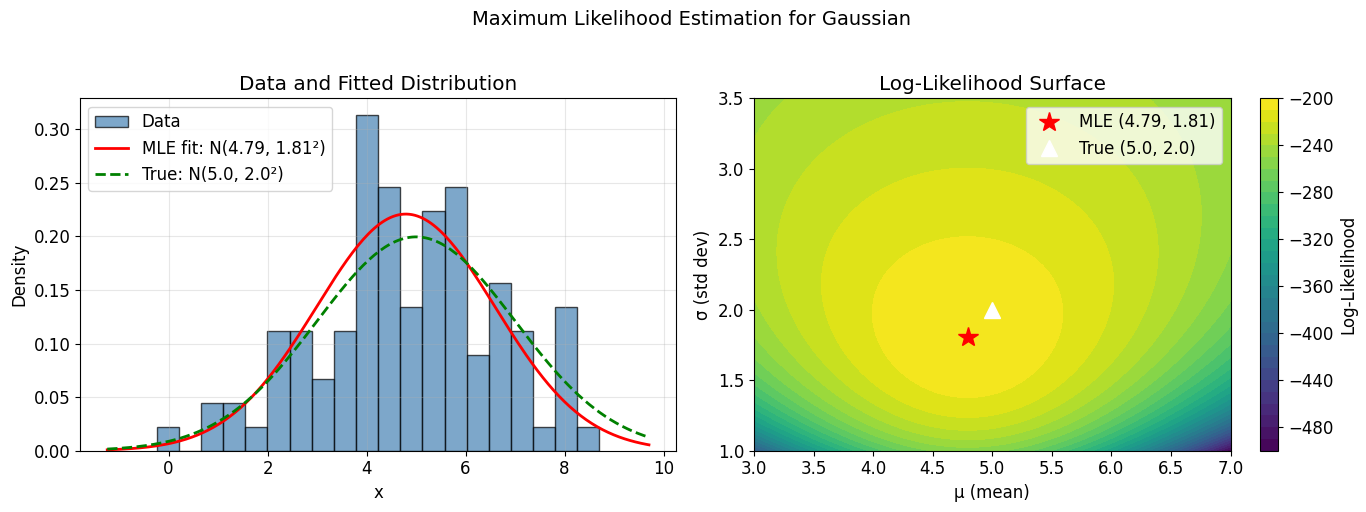

In [21]:
# Visualize the likelihood surface
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with fitted distribution
ax = axes[0]
ax.hist(data, bins=20, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Data')

x = np.linspace(data.min() - 1, data.max() + 1, 200)
ax.plot(x, norm.pdf(x, mu_mle, sigma_mle), 'r-', linewidth=2, 
        label=f'MLE fit: N({mu_mle:.2f}, {sigma_mle:.2f}²)')
ax.plot(x, norm.pdf(x, true_mu, true_sigma), 'g--', linewidth=2,
        label=f'True: N({true_mu}, {true_sigma}²)')

ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_title('Data and Fitted Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Log-likelihood surface
ax = axes[1]
mu_range = np.linspace(3, 7, 100)
sigma_range = np.linspace(1, 3.5, 100)
MU, SIGMA = np.meshgrid(mu_range, sigma_range)

LL = np.zeros_like(MU)
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        LL[i, j] = log_likelihood(data, MU[i, j], SIGMA[i, j])

contour = ax.contourf(MU, SIGMA, LL, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Log-Likelihood')

# Mark MLE and true parameters
ax.plot(mu_mle, sigma_mle, 'r*', markersize=15, label=f'MLE ({mu_mle:.2f}, {sigma_mle:.2f})')
ax.plot(true_mu, true_sigma, 'w^', markersize=12, label=f'True ({true_mu}, {true_sigma})')

ax.set_xlabel('μ (mean)')
ax.set_ylabel('σ (std dev)')
ax.set_title('Log-Likelihood Surface')
ax.legend(loc='upper right')

plt.suptitle('Maximum Likelihood Estimation for Gaussian', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Interactive MLE visualization
def explore_mle(mu_guess=5.0, sigma_guess=2.0):
    """Explore how changing parameters affects the likelihood."""
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.hist(data, bins=20, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Data')
    
    x = np.linspace(data.min() - 2, data.max() + 2, 200)
    
    # Plot guessed distribution
    ax.plot(x, norm.pdf(x, mu_guess, sigma_guess), 'r-', linewidth=2,
            label=f'Your guess: N({mu_guess:.1f}, {sigma_guess:.1f}²)')
    
    # Plot MLE distribution
    ax.plot(x, norm.pdf(x, mu_mle, sigma_mle), 'g--', linewidth=2,
            label=f'MLE: N({mu_mle:.2f}, {sigma_mle:.2f}²)')
    
    # Compute log-likelihoods
    ll_guess = log_likelihood(data, mu_guess, sigma_guess)
    
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.set_title(f'Log-Likelihood: Your guess = {ll_guess:.2f}, MLE = {ll_mle:.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Color title based on how close we are
    if ll_guess > ll_mle - 1:
        ax.set_title(ax.get_title(), color='green')
    elif ll_guess > ll_mle - 10:
        ax.set_title(ax.get_title(), color='orange')
    else:
        ax.set_title(ax.get_title(), color='red')
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(explore_mle,
         mu_guess=widgets.FloatSlider(min=2, max=8, step=0.1, value=4, description='μ guess'),
         sigma_guess=widgets.FloatSlider(min=0.5, max=4, step=0.1, value=1.5, description='σ guess'));

interactive(children=(FloatSlider(value=4.0, description='μ guess', max=8.0, min=2.0), FloatSlider(value=1.5, …

## Summary

In this notebook, we covered the essential probability and statistics concepts for machine learning:

1. **Probability Basics**: Sample spaces, events, and conditional probability with coin/dice examples
2. **Bayes' Theorem**: Updated beliefs with evidence (spam filter example)
3. **Key Distributions**: Bernoulli, Binomial, Gaussian, and Categorical
4. **Expectation & Variance**: Statistical measures and Monte Carlo estimation
5. **Multivariate Gaussian**: Covariance, correlation, and 2D visualizations
6. **Maximum Likelihood Estimation**: Learning parameters from data

### Key Takeaways for AI/ML:

- **Bayes' theorem** is the foundation of probabilistic inference and Bayesian neural networks
- **Gaussian distributions** model continuous data, noise, and latent variables
- **Categorical distributions** represent multi-class outputs (softmax)
- **MLE** is the foundation of training - minimizing cross-entropy loss = maximizing log-likelihood
- **Monte Carlo methods** enable tractable inference in complex models
- **Covariance** captures relationships between features - crucial for understanding data structure

---

*Continue to Chapter 3 for calculus foundations...*